# Spectral Clustering

## Learning Objectives

1. **Construct** the graph Laplacian $L = D - W$ and its normalised variant
2. **State** the connection between Fiedler vector and the minimum normalised cut
3. **Apply** the eigengap heuristic to select the number of clusters $k$
4. **Explain** why spectral clustering handles non-convex clusters that k-means cannot
5. **Implement** spectral clustering with RBF affinity and k-means in spectral space


## Problem Statement

### Limits of K-Means

K-means partitions data into convex Voronoi cells. It fails on non-convex clusters (two rings, two moons, interlocked spirals). Spectral clustering solves this by operating on a **graph similarity structure** rather than raw Euclidean distance.

### Similarity Graph

Given $n$ data points, build a similarity graph $G = (V, E, W)$:
- $\epsilon$-neighbourhood: connect $i$ and $j$ if $\|x_i - x_j\| < \epsilon$
- **RBF kernel (Gaussian):** $W_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$, $W_{ii} = 0$
- $k$-NN: connect each point to its $k$ nearest neighbours

### Graph Laplacian

The **unnormalized Laplacian:** $L = D - W$ where $D = \text{diag}(\sum_j W_{ij})$.

**Key property:** $x^\top L x = \frac{1}{2} \sum_{i,j} W_{ij}(x_i - x_j)^2 \geq 0$ — positive semi-definite.

The **number of zero eigenvalues** of $L$ equals the number of connected components. The **second smallest eigenvalue** $\lambda_2$ (Fiedler value) measures graph connectivity; its eigenvector $v_2$ (Fiedler vector) gives the best 2-cut.


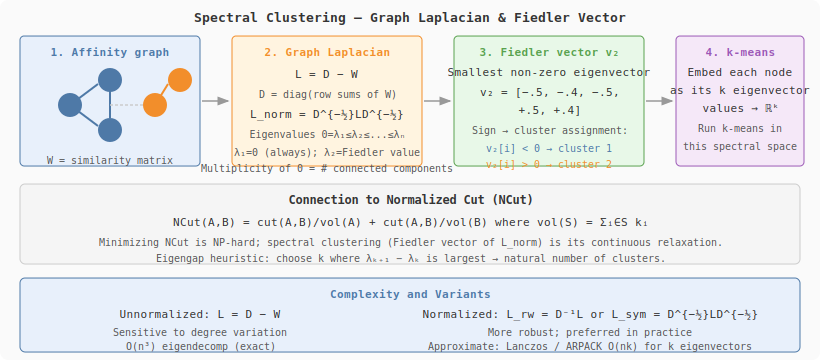

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Spectral Clustering — Graph Laplacian &amp; Fiedler Vector</text>

  <!-- Step 1: similarity graph -->
  <rect x="20" y="36" width="180" height="130" rx="4" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="110" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">1. Affinity graph</text>
  <circle cx="70"  cy="105" r="12" fill="#4e79a7"/><text x="70"  cy="109" text-anchor="middle" fill="white" font-size="9">A</text>
  <circle cx="110" cy="80"  r="12" fill="#4e79a7"/><text x="110" cy="84"  text-anchor="middle" fill="white" font-size="9">B</text>
  <circle cx="110" cy="130" r="12" fill="#4e79a7"/><text x="110" cy="134" text-anchor="middle" fill="white" font-size="9">C</text>
  <circle cx="155" cy="105" r="12" fill="#f28e2b"/><text x="155" cy="109" text-anchor="middle" fill="white" font-size="9">D</text>
  <circle cx="180" cy="80"  r="12" fill="#f28e2b"/><text x="180" cy="84"  text-anchor="middle" fill="white" font-size="9">E</text>
  <line x1="70" y1="105" x2="98" y2="84"  stroke="#4e79a7" stroke-width="2"/>
  <line x1="70" y1="105" x2="98" y2="126" stroke="#4e79a7" stroke-width="2"/>
  <line x1="110" y1="80" x2="110" y2="118" stroke="#4e79a7" stroke-width="2"/>
  <line x1="110" y1="105" x2="143" y2="105" stroke="#ccc" stroke-width="1.5" stroke-dasharray="3,2"/>
  <line x1="155" y1="105" x2="168" y2="84"  stroke="#f28e2b" stroke-width="2"/>
  <text x="110" y="164" text-anchor="middle" fill="#555" font-size="10">W = similarity matrix</text>

  <line x1="202" y1="101" x2="228" y2="101" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Step 2: Laplacian -->
  <rect x="232" y="36" width="190" height="130" rx="4" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="327" y="56" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">2. Graph Laplacian</text>
  <text x="327" y="78" text-anchor="middle" fill="#333" font-size="11">L = D − W</text>
  <text x="327" y="98" text-anchor="middle" fill="#555" font-size="10">D = diag(row sums of W)</text>
  <text x="327" y="118" text-anchor="middle" fill="#333" font-size="11">L_norm = D^{−½}LD^{−½}</text>
  <text x="327" y="138" text-anchor="middle" fill="#555" font-size="10">Eigenvalues 0=λ₁≤λ₂≤...≤λₙ</text>
  <text x="327" y="156" text-anchor="middle" fill="#555" font-size="10">λ₁=0 (always); λ₂=Fiedler value</text>
  <text x="327" y="172" text-anchor="middle" fill="#555" font-size="10">Multiplicity of 0 = # connected components</text>

  <line x1="424" y1="101" x2="450" y2="101" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Step 3: Fiedler vector -->
  <rect x="454" y="36" width="190" height="130" rx="4" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="549" y="56" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">3. Fiedler vector v₂</text>
  <text x="549" y="76" text-anchor="middle" fill="#333" font-size="11">Smallest non-zero eigenvector</text>
  <text x="549" y="96" text-anchor="middle" fill="#333" font-size="11">v₂ = [−.5, −.4, −.5,</text>
  <text x="549" y="114" text-anchor="middle" fill="#333" font-size="11">       +.5, +.4]</text>
  <text x="549" y="134" text-anchor="middle" fill="#555" font-size="10">Sign → cluster assignment:</text>
  <text x="549" y="152" text-anchor="middle" fill="#4e79a7" font-size="10">v₂[i] &lt; 0 → cluster 1</text>
  <text x="549" y="168" text-anchor="middle" fill="#f28e2b" font-size="10">v₂[i] &gt; 0 → cluster 2</text>

  <line x1="646" y1="101" x2="672" y2="101" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- Step 4: k-means on embeddings -->
  <rect x="676" y="36" width="128" height="130" rx="4" fill="#f5e8f8" stroke="#9b59b6"/>
  <text x="740" y="56" text-anchor="middle" fill="#9b59b6" font-size="11" font-weight="bold">4. k-means</text>
  <text x="740" y="76" text-anchor="middle" fill="#333" font-size="11">Embed each node</text>
  <text x="740" y="94" text-anchor="middle" fill="#333" font-size="11">as its k eigenvector</text>
  <text x="740" y="112" text-anchor="middle" fill="#333" font-size="11">values → ℝᵏ</text>
  <text x="740" y="132" text-anchor="middle" fill="#555" font-size="10">Run k-means in</text>
  <text x="740" y="150" text-anchor="middle" fill="#555" font-size="10">this spectral space</text>

  <!-- Normalized cut connection -->
  <rect x="20" y="184" width="780" height="80" rx="5" fill="#f5f5f5" stroke="#ccc"/>
  <text x="410" y="204" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">Connection to Normalized Cut (NCut)</text>
  <text x="410" y="226" text-anchor="middle" fill="#333" font-size="11">NCut(A,B) = cut(A,B)/vol(A) + cut(A,B)/vol(B)   where vol(S) = Σᵢ∈S kᵢ</text>
  <text x="410" y="246" text-anchor="middle" fill="#555" font-size="10">Minimizing NCut is NP-hard; spectral clustering (Fiedler vector of L_norm) is its continuous relaxation.</text>
  <text x="410" y="262" text-anchor="middle" fill="#555" font-size="10">Eigengap heuristic: choose k where λₖ₊₁ − λₖ is largest → natural number of clusters.</text>

  <!-- Complexity -->
  <rect x="20" y="278" width="780" height="74" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="410" y="298" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Complexity and Variants</text>
  <text x="200" y="318" text-anchor="middle" fill="#333" font-size="11">Unnormalized: L = D − W</text>
  <text x="200" y="336" text-anchor="middle" fill="#555" font-size="10">Sensitive to degree variation</text>
  <text x="200" y="350" text-anchor="middle" fill="#555" font-size="10">O(n³) eigendecomp (exact)</text>
  <text x="590" y="318" text-anchor="middle" fill="#333" font-size="11">Normalized: L_rw = D⁻¹L or L_sym = D^{−½}LD^{−½}</text>
  <text x="590" y="336" text-anchor="middle" fill="#555" font-size="10">More robust; preferred in practice</text>
  <text x="590" y="350" text-anchor="middle" fill="#555" font-size="10">Approximate: Lanczos / ARPACK O(nk) for k eigenvectors</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Normalised Cut and Spectral Relaxation

For two clusters $A, B = V \setminus A$, the **normalised cut** is:
$$\text{NCut}(A, B) = \frac{\text{cut}(A,B)}{\text{vol}(A)} + \frac{\text{cut}(A,B)}{\text{vol}(B)}$$
where $\text{cut}(A,B) = \sum_{i \in A, j \in B} W_{ij}$ and $\text{vol}(S) = \sum_{i \in S} k_i$.

Minimising NCut is NP-hard. The **continuous relaxation** using indicator vector $f \in \{-1, +1\}^n$:
$$\min_f \frac{f^\top L f}{f^\top D f} \quad \text{s.t.} \quad f \perp \mathbf{1}$$

This generalised eigenvalue problem $L f = \lambda D f$ has solution $f^* = D^{-1/2} v_2$ where $v_2$ is the Fiedler vector of $L_{\text{sym}} = D^{-1/2} L D^{-1/2}$.

### Algorithm for $k > 2$ Clusters

Use the $k$ smallest eigenvectors of $L_{\text{sym}}$ as a $k$-dimensional embedding of each node, then run k-means on this embedding.

**Eigengap heuristic:** Choose $k$ such that $\lambda_{k+1} - \lambda_k$ is large — a large gap indicates $k$ is the "natural" number of clusters.

### Normalised vs Unnormalised

| | Unnormalised ($L$) | Normalised ($L_{\text{sym}}$) |
|--|--|--|
| Objective | RatioCut | NCut |
| Sensitivity | Sensitive to degree | More robust |
| Preferred | Equal-size clusters | General use |


## Algorithm Steps

1. **Build** affinity matrix $W$ (e.g. RBF kernel)
2. **Compute** degree matrix $D$ and Laplacian $L = D - W$ (or $L_{\text{sym}}$)
3. **Eigendecompose** $L$; take $k$ eigenvectors with smallest non-zero eigenvalues $\to$ matrix $X \in \mathbb{R}^{n \times k}$
4. **Row-normalise** $X$ (for normalised variant)
5. **Run k-means** on rows of $X$; return cluster labels


In [2]:
import numpy as np
from sklearn.cluster import KMeans


def spectral_clustering(W, k, mode='normalized', seed=42):
    """
    Spectral clustering on a weighted adjacency matrix.

    Inputs
    ------
    W    : np.ndarray (n, n) — symmetric affinity/weight matrix
    k    : int — number of clusters
    mode : 'normalized' (Lrw = D⁻¹L) or 'unnormalized' (L = D − W)

    Returns
    -------
    labels : np.ndarray (n,) — cluster assignment
    eigvals : first k+1 eigenvalues (for eigengap analysis)
    """
    n = W.shape[0]
    d = W.sum(axis=1)
    D = np.diag(d)
    L = D - W

    if mode == 'normalized':
        # L_sym = D^{-1/2} L D^{-1/2}
        d_inv_sqrt = np.where(d > 0, d**(-0.5), 0)
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L_sym = D_inv_sqrt @ L @ D_inv_sqrt
    else:
        L_sym = L

    # Eigendecomposition (symmetric → real eigenvalues)
    eigvals, eigvecs = np.linalg.eigh(L_sym)

    # Take k smallest eigenvectors (skip λ₁=0)
    X = eigvecs[:, :k]

    # Row-normalise (for L_sym → get approximate L_rw eigenvectors)
    if mode == 'normalized':
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms = np.where(norms > 0, norms, 1.0)
        X = X / norms

    # k-means in spectral space
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = km.fit_predict(X)

    return labels, eigvals[:k+2]


def rbf_similarity(points, sigma=1.0):
    """Gaussian RBF kernel: Wᵢⱼ = exp(−‖xᵢ−xⱼ‖²/2σ²)"""
    diff = points[:, np.newaxis] - points[np.newaxis, :]
    dist2 = (diff**2).sum(axis=2)
    W = np.exp(-dist2 / (2 * sigma**2))
    np.fill_diagonal(W, 0)
    return W


# ── Demo: two concentric rings ─────────────────────────────────────────────
rng = np.random.default_rng(0)
t1 = np.linspace(0, 2*np.pi, 80)
t2 = np.linspace(0, 2*np.pi, 80)
inner = np.column_stack([np.cos(t1) * 1.0, np.sin(t1) * 1.0]) + rng.normal(0, 0.1, (80, 2))
outer = np.column_stack([np.cos(t2) * 2.5, np.sin(t2) * 2.5]) + rng.normal(0, 0.1, (80, 2))
points = np.vstack([inner, outer])
true_labels = np.array([0]*80 + [1]*80)

W = rbf_similarity(points, sigma=0.5)
labels, eigvals = spectral_clustering(W, k=2, mode='normalized')

# Accuracy (handle label flip)
acc = max(np.mean(labels == true_labels), np.mean(labels != true_labels))
print(f"Spectral clustering accuracy on concentric rings: {acc*100:.1f}%")
print(f"First 4 eigenvalues: {eigvals[:4].round(4)}")
print(f"Eigengap (λ₂−λ₁): {eigvals[1]-eigvals[0]:.4f}")
print(f"Eigengap (λ₃−λ₂): {eigvals[2]-eigvals[1]:.4f}")
print("(Large gap at k=2 confirms 2 natural clusters)")

# Compare: k-means on raw points fails on rings
from sklearn.cluster import KMeans as KM
km_labels = KM(n_clusters=2, random_state=0, n_init=10).fit_predict(points)
km_acc = max(np.mean(km_labels == true_labels), np.mean(km_labels != true_labels))
print(f"\nRaw k-means accuracy on rings: {km_acc*100:.1f}%  (spectral wins for non-convex clusters)")


Spectral clustering accuracy on concentric rings: 100.0%
First 4 eigenvalues: [0.     0.0324 0.0435 0.048 ]
Eigengap (λ₂−λ₁): 0.0324
Eigengap (λ₃−λ₂): 0.0110
(Large gap at k=2 confirms 2 natural clusters)

Raw k-means accuracy on rings: 50.6%  (spectral wins for non-convex clusters)
